# ============================================================
# Author: Mayur Deshmukh
# Name: 02_eda.ipynb
# Project: ML-Binary-Classifier-For-Stock-Price-Prediction
# Purpose: Exploratory Data Analysis
# Python Version: 3.11
# ============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
output_dir = os.path.join('..', '..', 'output')

In [2]:
# ── Load Dataset ────────────────────────────────────────────────────────────────

df = pd.read_csv(os.path.join(output_dir, 'filtered_stocks.csv'), parse_dates=['date'])
print(f"Shape: {df.shape}")
print(f"Tickers: {df['Name'].unique().tolist()}")
df.head()

Shape: (12590, 8)
Tickers: ['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'WMT', 'ZTS']


,date,open,high,low,close,volume,Name,target
0,2013-02-08,45.07,45.35,45.00,45.08,1824755,A,0
1,2013-02-11,45.17,45.18,44.45,44.60,2915405,A,0
2,2013-02-12,44.81,44.95,44.50,44.62,2373731,A,1
3,2013-02-13,44.81,45.24,44.68,44.75,2052338,A,1
4,2013-02-14,44.72,44.78,44.36,44.58,3826245,A,0


In [3]:
# ── Descriptive Statistics ──────────────────────────────────────────────────────

print("=== Data Types & Nulls ===")
print(df.info())

print("\n=== Descriptive Statistics (numeric) ===")
display(df.describe().T.round(2))

print("\n=== Target Distribution (overall) ===")
target_dist = df['target'].value_counts(normalize=True).mul(100).round(2).rename({0: 'Down %', 1: 'Up %'})
print(target_dist)

print("\n=== Target Distribution per Ticker ===")
ticker_target = (df.groupby('Name')['target']
                   .value_counts(normalize=True)
                   .mul(100).round(2)
                   .rename('pct').reset_index())
ticker_target['target'] = ticker_target['target'].map({1: 'Up', 0: 'Down'})
display(ticker_target.pivot(index='Name', columns='target', values='pct').reset_index())

=== Data Types & Nulls ===
<class 'pandas.DataFrame'>
RangeIndex: 12590 entries, 0 to 12589
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    12590 non-null  datetime64[us]
 1   open    12590 non-null  float64       
 2   high    12590 non-null  float64       
 3   low     12590 non-null  float64       
 4   close   12590 non-null  float64       
 5   volume  12590 non-null  int64         
 6   Name    12590 non-null  str           
 7   target  12590 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(1)
memory usage: 823.9 KB
None

=== Descriptive Statistics (numeric) ===


,count,mean,min,25%,50%,75%,max,std
date,12590,2015-08-09 05:44:16.393963,2013-02-08 00:00:00,2014-05-09 00:00:00,2015-08-10 00:00:00,2016-11-07 00:00:00,2018-02-07 00:00:00,NaN
open,12590.0,73.637262,13.14,45.57,65.925,92.07,201.24,35.499143
high,12590.0,74.299728,13.42,45.97,66.46,92.78,201.24,35.788473
low,12590.0,72.985399,12.7,45.13125,65.385,91.2775,198.16,35.204887
close,12590.0,73.663463,13.02,45.6125,65.98,92.0975,200.38,35.506565
volume,12590.0,9814856.706354,130712.0,1975291.5,4203089.5,8123794.5,266833581.0,18713825.432424
target,12590.0,0.522637,0.0,0.0,1.0,1.0,1.0,0.499507



=== Target Distribution (overall) ===
target
Up %      52.26
Down %    47.74
Name: proportion, dtype: float64

=== Target Distribution per Ticker ===


target,Name,Down,Up
0,A,47.74,52.26
1,AAL,47.26,52.74
2,AAP,49.56,50.44
3,AAPL,48.37,51.63
4,ABBV,46.47,53.53
5,ABC,46.15,53.85
6,ABT,49.56,50.44
7,ACN,46.07,53.93
8,WMT,47.74,52.26
9,ZTS,48.45,51.55


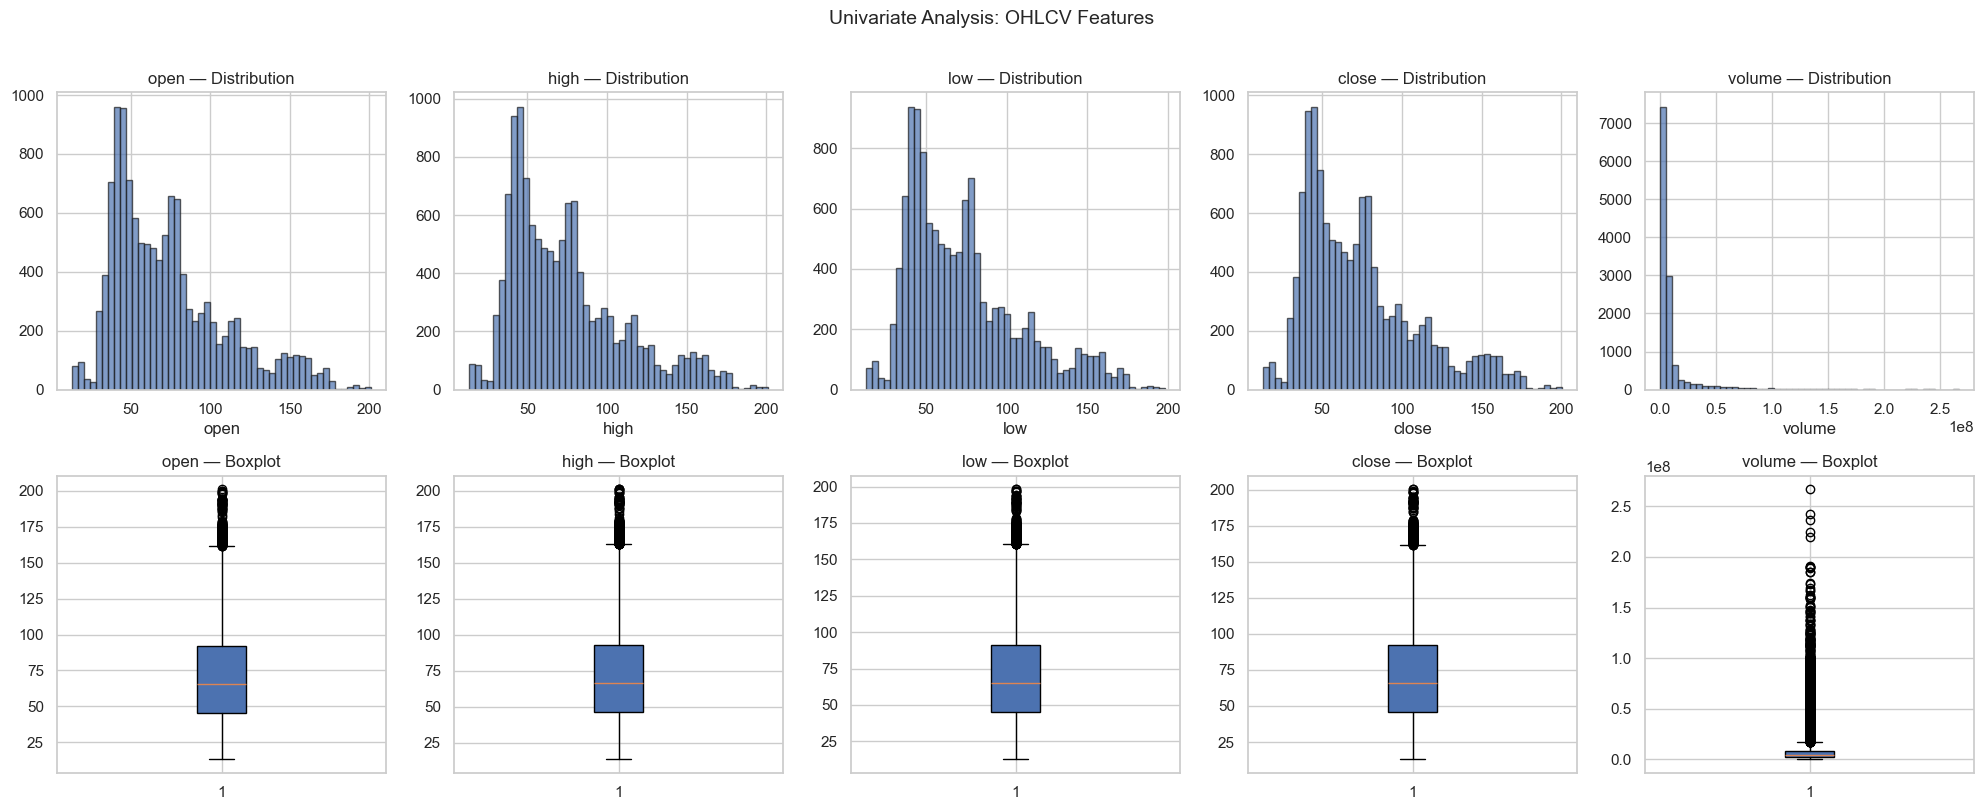

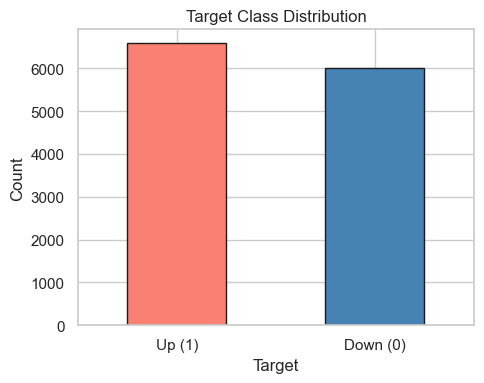

In [4]:
# ── Univariate Analysis ─────────────────────────────────────────────────────────

num_cols = ['open', 'high', 'low', 'close', 'volume']

fig, axes = plt.subplots(2, len(num_cols), figsize=(20, 8))
for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=50, edgecolor='k', alpha=0.7)
    axes[0, i].set_title(f'{col} — Distribution')
    axes[0, i].set_xlabel(col)
    # Boxplot
    axes[1, i].boxplot(df[col], vert=True, patch_artist=True)
    axes[1, i].set_title(f'{col} — Boxplot')

plt.suptitle('Univariate Analysis: OHLCV Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'univariate_analysis.png'), bbox_inches='tight')
plt.show()

# Target class balance bar chart
fig, ax = plt.subplots(figsize=(5, 4))
df['target'].value_counts().rename({0: 'Down (0)', 1: 'Up (1)'}).plot(kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='k')
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Target')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'target_distribution.png'), bbox_inches='tight')
plt.show()

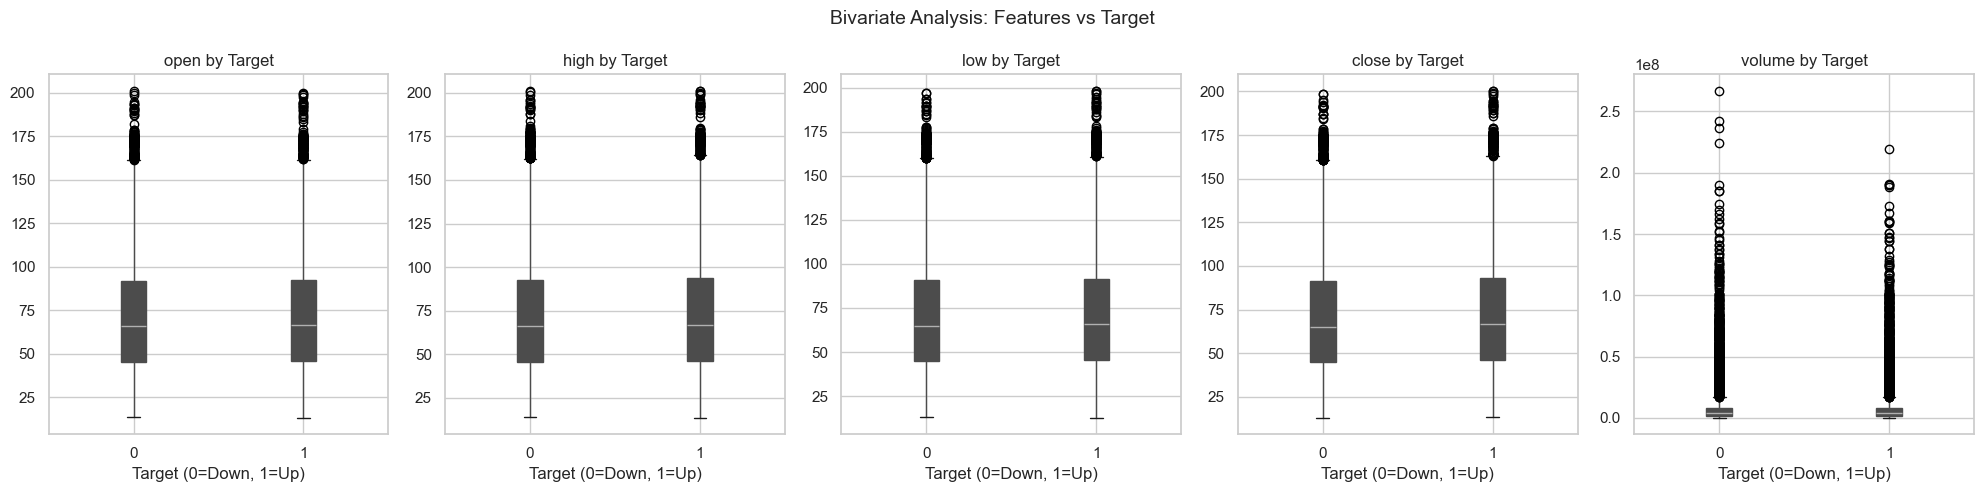

=== Mean feature values by target ===


,open,high,low,close,volume
target,,,,,
0,73.74,74.14,72.78,73.19,10071744.39
1,73.54,74.45,73.17,74.09,9580222.21


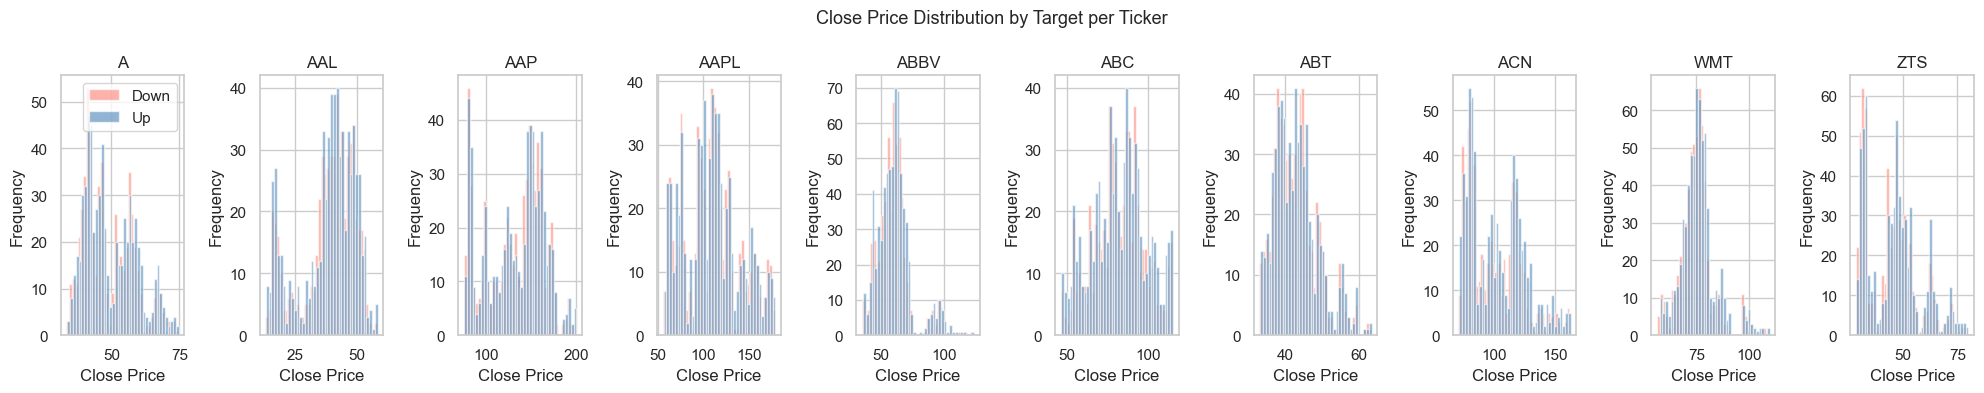

In [5]:
# ── Bivariate Analysis ──────────────────────────────────────────────────────────

# Boxplots of OHLCV features split by target
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='target', ax=axes[i], patch_artist=True)
    axes[i].set_title(f'{col} by Target')
    axes[i].set_xlabel('Target (0=Down, 1=Up)')

plt.suptitle('Bivariate Analysis: Features vs Target', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'bivariate_analysis.png'), bbox_inches='tight')
plt.show()

# Mean feature values per target
print("=== Mean feature values by target ===")
display(df.groupby('target')[num_cols].mean().round(2))

# Close price distribution per ticker coloured by target
fig, axes = plt.subplots(1, len(df['Name'].unique()), figsize=(20, 4), sharey=False)
for ax, ticker in zip(axes, sorted(df['Name'].unique())):
    sub = df[df['Name'] == ticker]
    for label, color in [(0, 'salmon'), (1, 'steelblue')]:
        sub[sub['target'] == label]['close'].plot(kind='hist', bins=40, alpha=0.6, color=color, ax=ax)
    ax.set_title(ticker)
    ax.set_xlabel('Close Price')
axes[0].legend(['Down', 'Up'])
plt.suptitle('Close Price Distribution by Target per Ticker', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'close_by_target_per_ticker.png'), bbox_inches='tight')
plt.show()

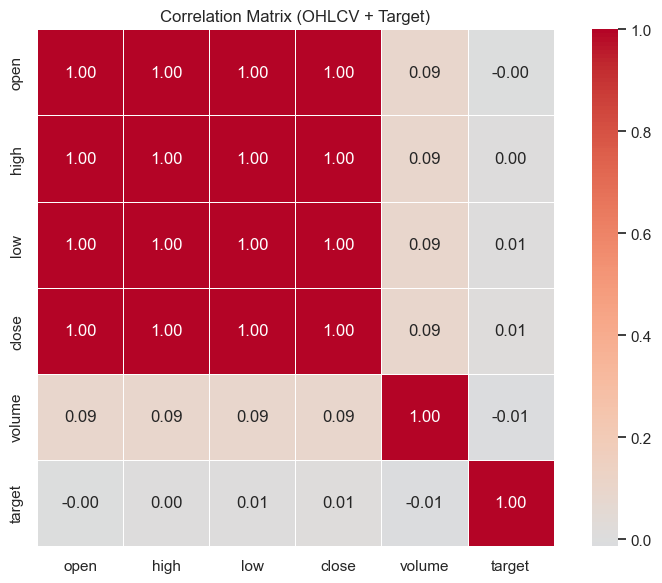

=== Correlation with Target ===
close     0.0127
low       0.0056
high      0.0044
open     -0.0028
volume   -0.0131
Name: target, dtype: float64


In [6]:
# ── Correlation Analysis ────────────────────────────────────────────────────────

corr_cols = num_cols + ['target']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (OHLCV + Target)')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_matrix.png'), bbox_inches='tight')
plt.show()

print("=== Correlation with Target ===")
print(corr_matrix['target'].drop('target').sort_values(ascending=False).round(4))

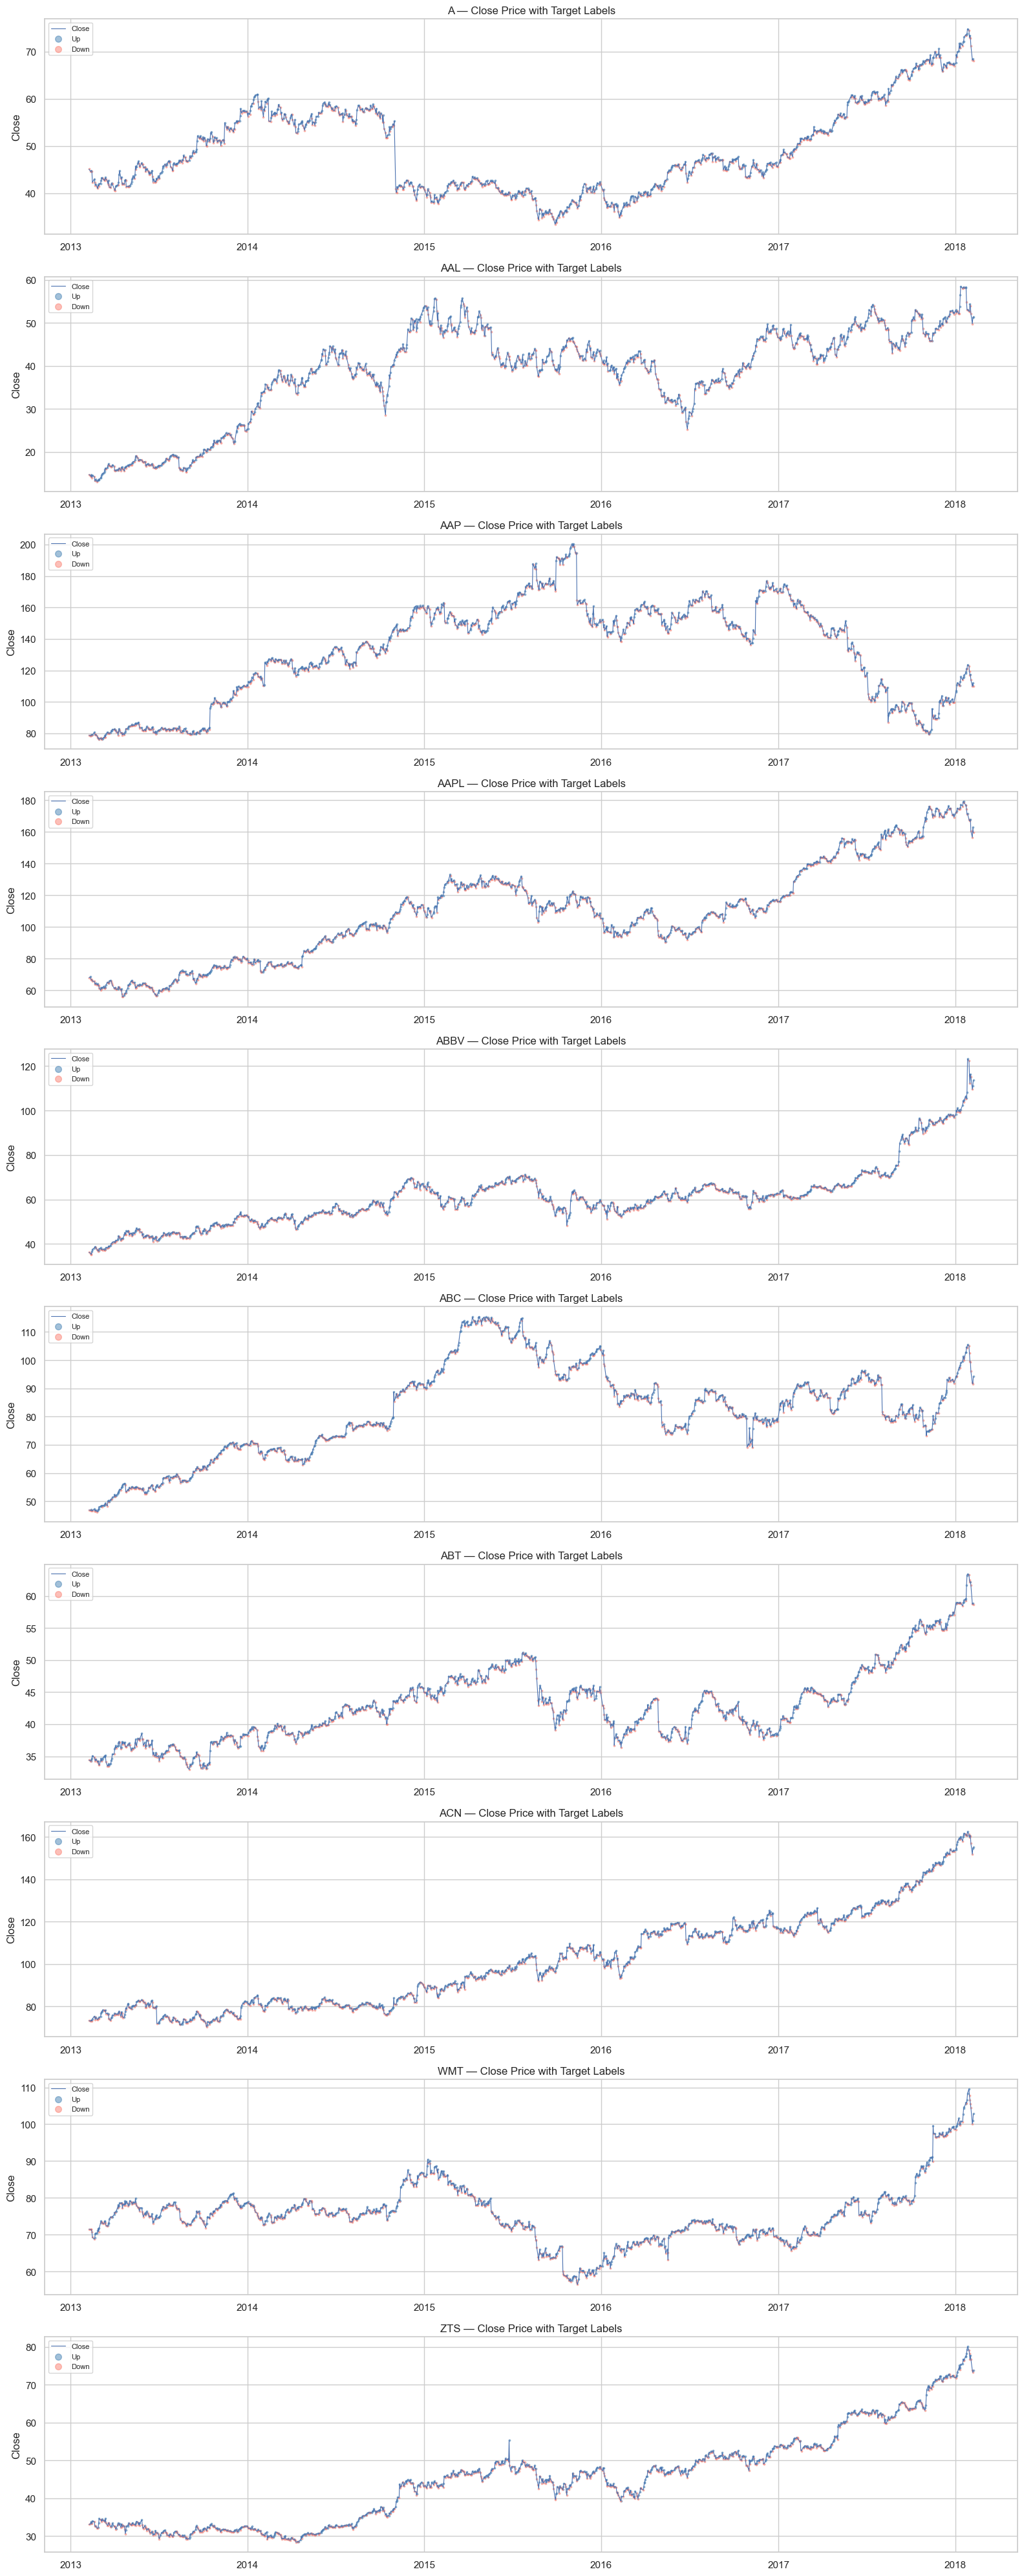

In [7]:
# ── Time Series: Closing Price per Ticker ───────────────────────────────────────

fig, axes = plt.subplots(len(df['Name'].unique()), 1,
                         figsize=(16, 4 * len(df['Name'].unique())), sharex=False)

for ax, ticker in zip(axes, sorted(df['Name'].unique())):
    sub = df[df['Name'] == ticker].set_index('date')
    ax.plot(sub['close'], label='Close', linewidth=0.8)
    up_days   = sub[sub['target'] == 1]
    down_days = sub[sub['target'] == 0]
    ax.scatter(up_days.index,   up_days['close'],   color='steelblue', s=3, alpha=0.5, label='Up')
    ax.scatter(down_days.index, down_days['close'], color='salmon',    s=3, alpha=0.5, label='Down')
    ax.set_title(f'{ticker} — Close Price with Target Labels')
    ax.set_ylabel('Close')
    ax.legend(loc='upper left', markerscale=4, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'close_price_timeseries.png'), bbox_inches='tight')
plt.show()

In [8]:
# ── Save EDA-ready Dataset ──────────────────────────────────────────────────────

eda_path = os.path.join(output_dir, 'eda_stocks.csv')
df.to_csv(eda_path, index=False)
print(f"EDA dataset saved to: {eda_path} | Shape: {df.shape}")

EDA dataset saved to: ..\..\output\eda_stocks.csv | Shape: (12590, 8)
